# Correlation Analysis Between Selected Financial Instruments

The aim of the analysis is to show how prices have changed and whether there are correlations between the prices of selected financial instruments (stock indices, commodities, cryptocurrencies, currency pairs).

### Data load
---

In [1]:
import pandas as pd

import src.data_loader as dl
import src.analytics as aly
import src.plotting as pl
from scipy import stats

data = dl.DataManager('../database_2026-03-04')
data.load_everything()

### 1. Market leaders data overview
---

At the beginning, key financial instruments relevant to the study were selected from the dataset, including Bitcoin, Gold, Brent Crude Oil, S&P 500, EURO STOXX 50, and USD/PLN. Daily percentage price changes were then computed based on closing prices from consecutive trading days.

In [2]:
selected = ["Bitcoin", "Gold", "Brent Crude Oil", "S&P 500", "EURO STOXX 50", "USDPLN"]
returns_sel = data.close_returns[selected].dropna()
close_prices_sel = data.close_prices[selected].dropna()

In the first stage, the key descriptive statistics for daily price changes were computed, including the mean, standard deviation, minimum, maximum, kurtosis, and skewness, among others.

In [3]:
returns_sel.describe().round(3)

,Bitcoin,Gold,Brent Crude Oil,S&P 500,EURO STOXX 50,USDPLN
count,3069.000,3069.000,3069.000,3069.000,3069.000,3069.000
mean,0.523,0.035,0.093,0.058,0.051,0.003
std,5.818,1.063,2.170,1.081,1.238,0.777
min,-38.812,-11.386,-24.404,-9.511,-12.401,-4.011
25%,-1.473,-0.472,-1.010,-0.382,-0.571,-0.447
50%,0.146,0.036,0.135,0.074,0.069,-0.008
75%,2.149,0.588,1.147,0.574,0.673,0.427
max,123.881,6.070,21.019,9.515,9.236,5.040


The data cover 3 069 days after removing missing values.
The average daily price change is slightly above zero in each case.
Bitcoin — the main cryptocurrency — exhibits the highest volatility, followed by Brent crude oil. Bitcoin also shows the most extreme price movements, with Brent oil coming second. The least volatile asset is the USD/PLN currency pair.

The means that are significantly different from zero at the 5% significance level are highlighted in color below.

In [4]:
mean = aly.mean_significance(returns_sel)
(pd.DataFrame(mean["mean"])
 .style.apply(
    pl.highlight_significant(mean["p_value"], lvl=0.05), axis=None))

,mean
Bitcoin,0.523298
Gold,0.035204
Brent Crude Oil,0.092660
S&P 500,0.058010
EURO STOXX 50,0.050536
USDPLN,0.003177


The “win rate,” representing the percentage of days with a positive return, was also calculated.

In [5]:
win_r = aly.sign_test(returns_sel, alternative='greater')
(pd.DataFrame(win_r["win_rate"])
 .style.apply(
    pl.highlight_significant(mean["p_value"], lvl=0.05), axis=None))

,win_rate
Bitcoin,52.297165
Gold,52.557836
Brent Crude Oil,53.144347
S&P 500,54.838710
EURO STOXX 50,53.372434
USDPLN,49.527533


Bitcoin, oil, and equity indices have a positive average daily return (significantly different from zero). Moreover, they exhibit a statistically significant tendency to have positive daily returns more often than negative ones, indicating that the market experienced more periods of growth than decline.

In [6]:
returns_sel.kurtosis().rename("kurtosis - 3")

Bitcoin            81.843542
Gold                7.667030
Brent Crude Oil    12.217253
S&P 500            10.431578
EURO STOXX 50       7.126645
USDPLN              3.043592
Name: kurtosis, dtype: float64

In [7]:
returns_sel.skew().rename("skewness")

Bitcoin            4.561607
Gold              -0.664950
Brent Crude Oil    0.056974
S&P 500            0.059590
EURO STOXX 50     -0.354205
USDPLN             0.305801
Name: skewness, dtype: float64

The distributions exhibit heavy tails, with Bitcoin showing a clearly stronger effect than the other assets. This implies that Bitcoin, as well as Brent crude oil and the S&P 500, have a systematically higher probability of extreme movements than would be expected under a normal distribution.
Moreover, Bitcoin’s daily price changes are positively skewed, indicating a higher frequency of large positive outliers. The opposite pattern is observed for gold — although less pronounced — where negative extreme movements occur more frequently.

### 2. Market correlation analysis
---

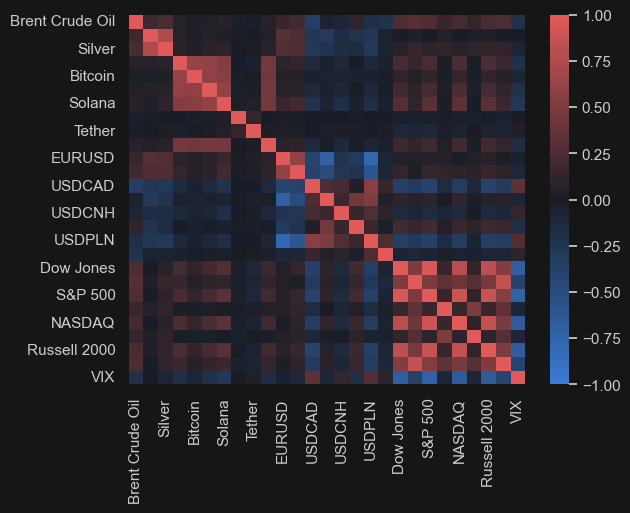

In [8]:
returns = data.close_returns
pear_cor, pear_p_vals = aly.correlations(returns, "pearson")
spear_cor, spear_p_vals = aly.correlations(returns, "spearman")
pl.heatmap_corr(pear_cor)

In [9]:
aly.corr_score(pear_cor, pear_p_vals).rename("Pearson (sum)")

S&P 500            7.762866
Russell 2000       7.403336
Dow Jones          7.399106
NASDAQ             7.060874
USDPLN             6.899374
USDCAD             6.261329
VIX                6.225259
EURO STOXX 50      6.187851
FTSE 100           5.899097
Solana             5.173652
GBPUSD             4.938057
EURUSD             4.752122
Binance Coin       4.491698
Ethereum           4.263892
Brent Crude Oil    4.022097
Silver             3.996124
USDCHF             3.966386
XRP                3.594271
USDCNH             3.347854
USDJPY             3.274409
Bitcoin            3.260758
Gold               3.057529
Hang Seng Index    2.861586
Nikkei 225         2.278195
USDRUB             1.743490
Tether             0.733569
USD Coin           0.134503
Name: Pearson (sum), dtype: float64

In [10]:
aly.corr_score(spear_cor, spear_p_vals).rename("Spearman (sum)")

S&P 500            7.375300
Russell 2000       7.062157
NASDAQ             6.923571
Dow Jones          6.905744
USDPLN             6.819790
VIX                6.308500
USDCAD             5.870700
EURO STOXX 50      5.578210
Solana             5.534274
FTSE 100           5.101969
EURUSD             5.095708
Ethereum           5.007475
XRP                4.943745
Binance Coin       4.926116
GBPUSD             4.789320
USDCHF             4.745663
Silver             4.184340
Bitcoin            4.089501
Brent Crude Oil    3.755122
Gold               3.461954
USDCNH             3.360268
USDRUB             3.337415
USDJPY             3.330109
Hang Seng Index    2.668926
Nikkei 225         1.889947
Tether             1.360914
USD Coin           0.220778
Name: Spearman (sum), dtype: float64

### 3. Market leaders analysis
---

In [11]:
(pear_cor.loc[selected, selected]
 .style.format("{:.3f}")
 .apply(pl.highlight_significant(pear_p_vals.loc[selected, selected], lvl=0.05), axis=None))

,Bitcoin,Gold,Brent Crude Oil,S&P 500,EURO STOXX 50,USDPLN
Bitcoin,1.000,0.026,0.030,0.119,0.056,-0.044
Gold,0.026,1.000,0.182,0.005,-0.003,-0.269
Brent Crude Oil,0.030,0.182,1.000,0.259,0.257,-0.181
S&P 500,0.119,0.005,0.259,1.000,0.532,-0.376
EURO STOXX 50,0.056,-0.003,0.257,0.532,1.000,-0.321
USDPLN,-0.044,-0.269,-0.181,-0.376,-0.321,1.000


In [12]:
reg, reg_pvals = aly.regression(returns_sel)
(reg.loc[selected, selected]
 .style.format("{:.3f}")
 .apply(pl.highlight_significant(reg_pvals.loc[selected, selected], lvl=0.05), axis=None))

,Bitcoin,Gold,Brent Crude Oil,S&P 500,EURO STOXX 50,USDPLN
Bitcoin,1.000,0.005,0.010,0.022,0.012,-0.007
Gold,0.152,1.000,0.286,0.071,0.032,-0.180
Brent Crude Oil,0.074,0.069,1.000,0.143,0.138,-0.048
S&P 500,0.649,0.069,0.576,1.000,0.662,-0.263
EURO STOXX 50,0.265,0.023,0.423,0.504,1.000,-0.189
USDPLN,-0.368,-0.337,-0.371,-0.509,-0.480,1.000


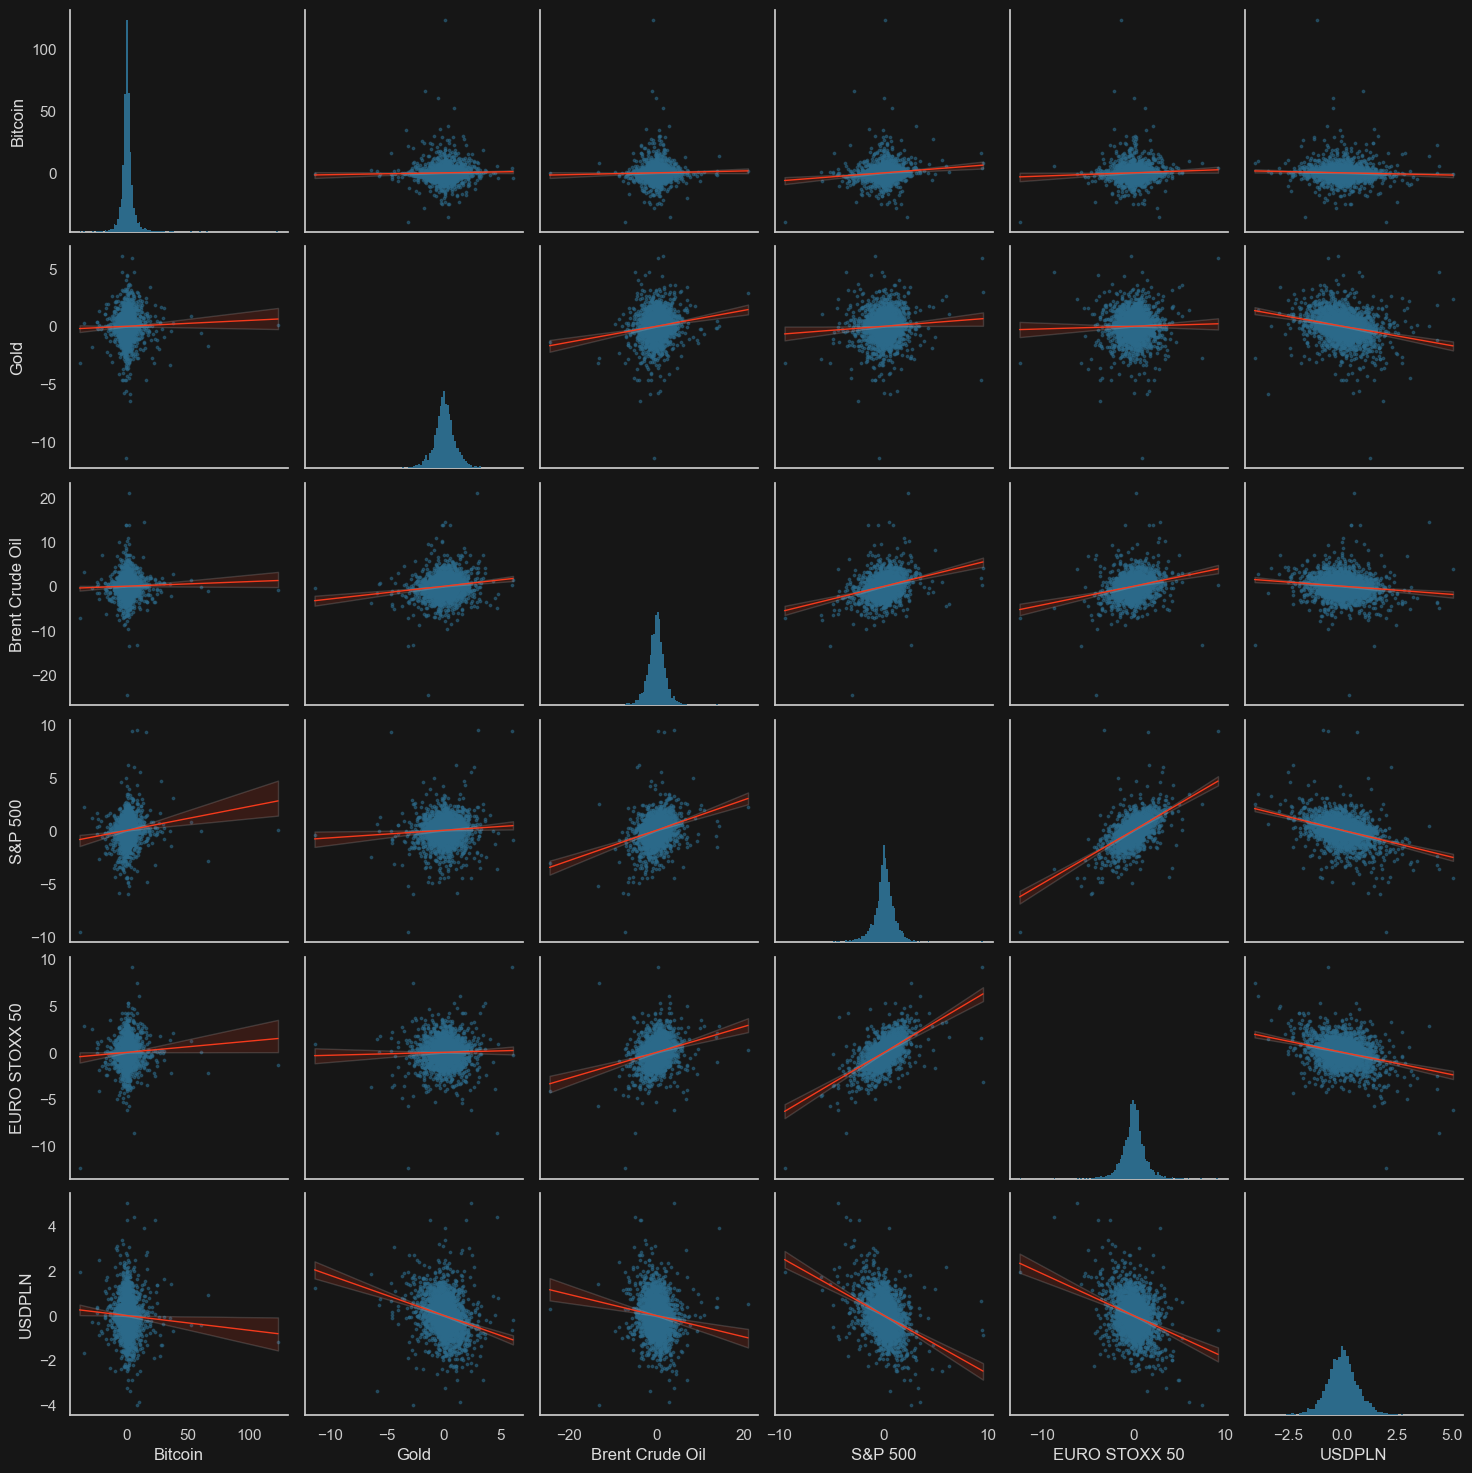

In [13]:
pl.price_change_distributions(returns_sel)

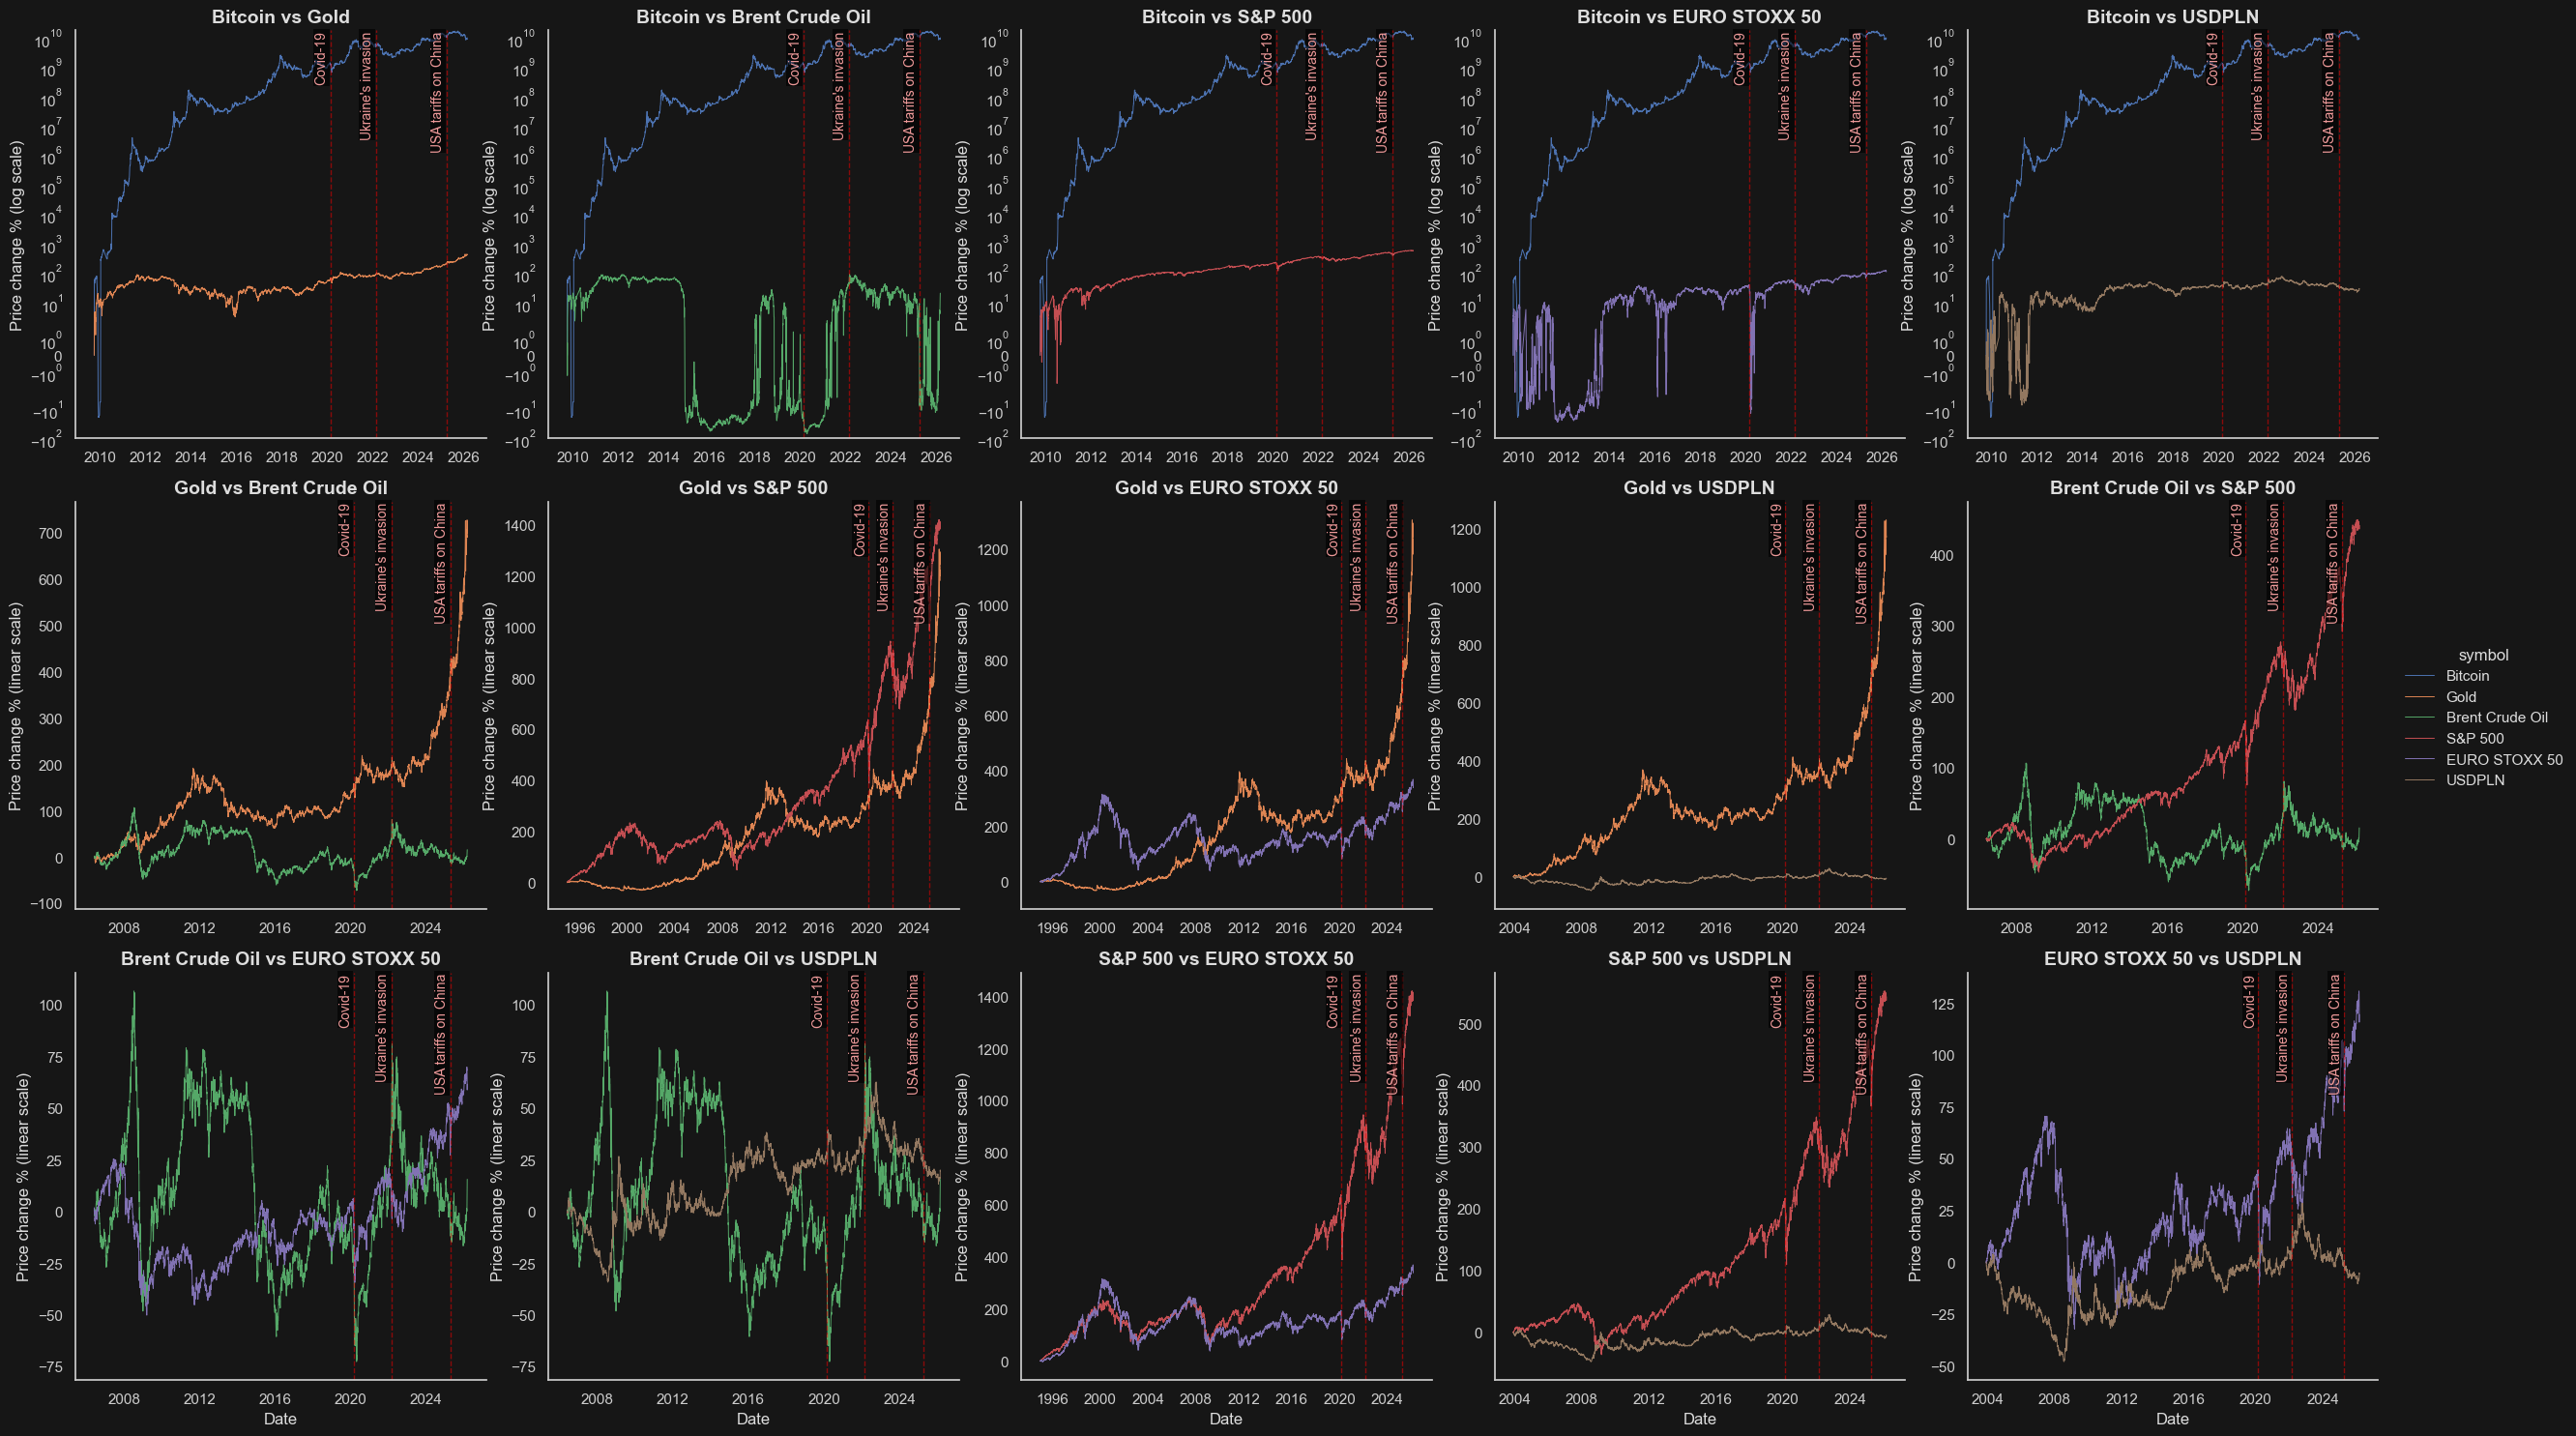

In [14]:
combinations = aly.make_pairs(selected)

pl.comparison_plot(data.close_prices, combinations)


### 4. Trends and volatility
---

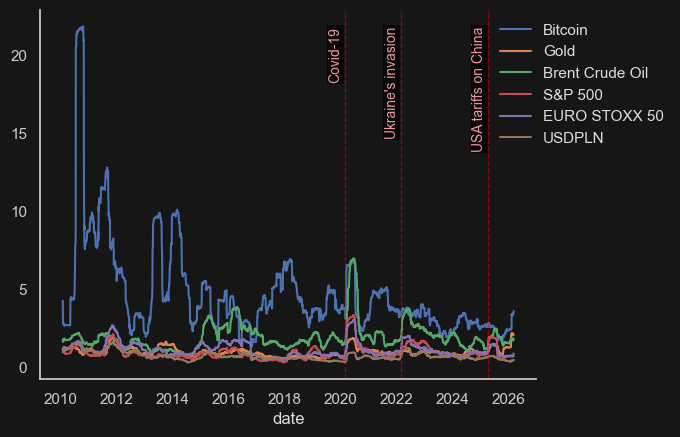

In [15]:
pl.rolling_volatility_plot(returns_sel, window=60)

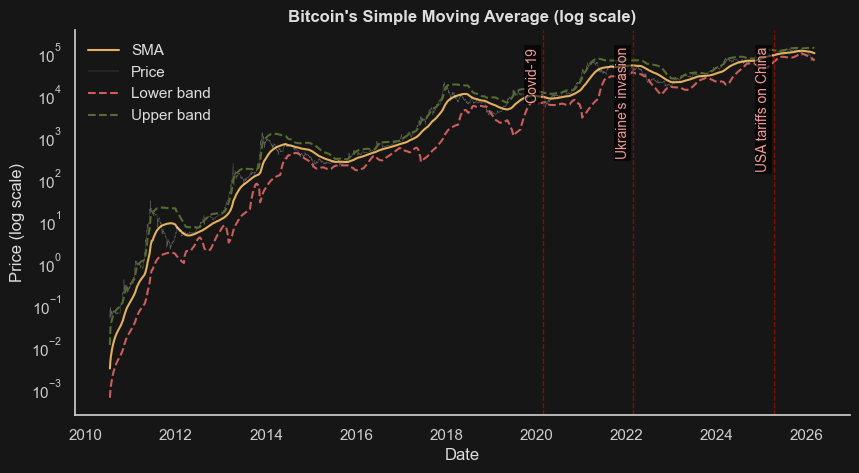

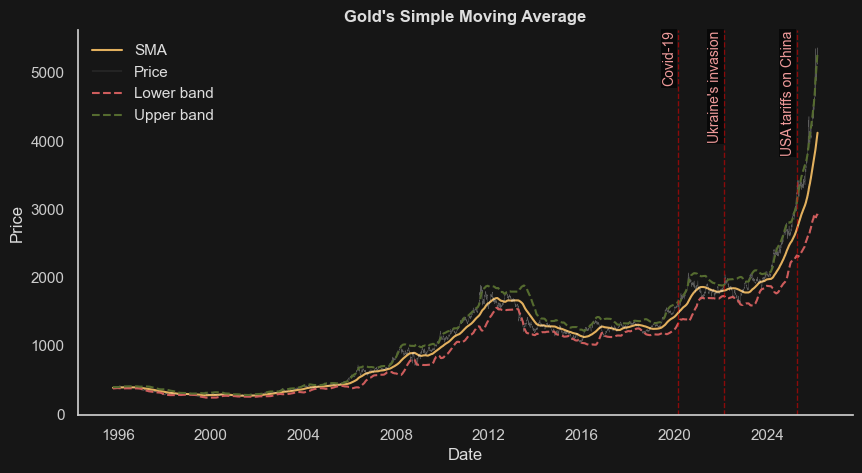

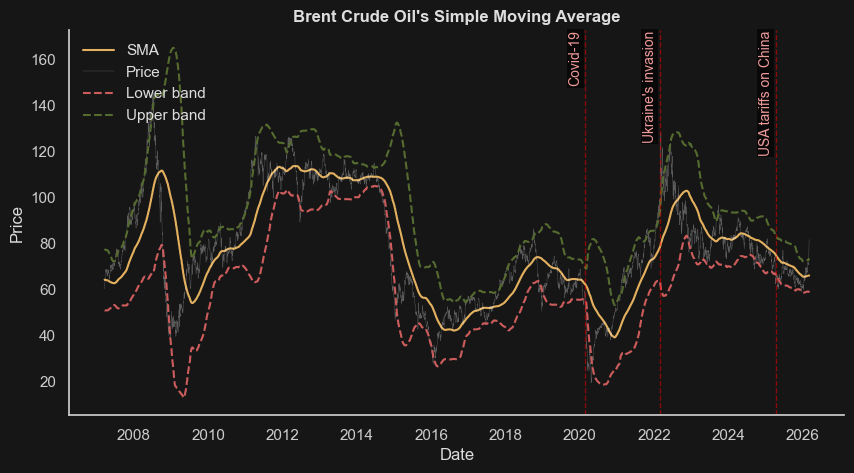

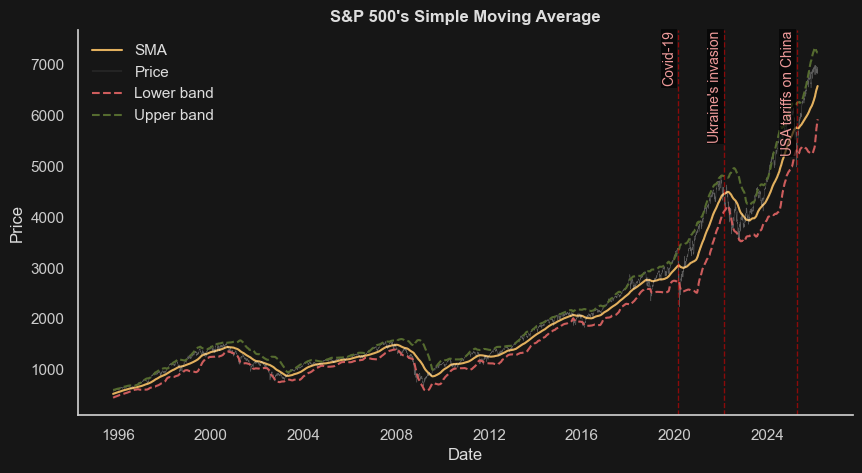

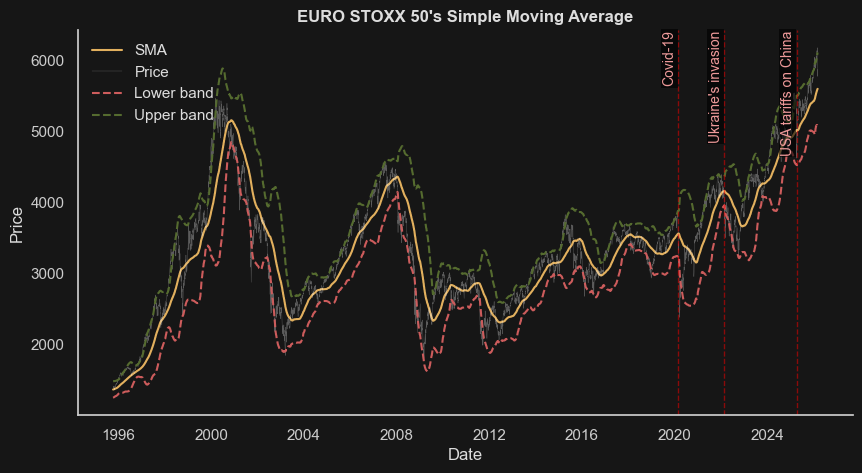

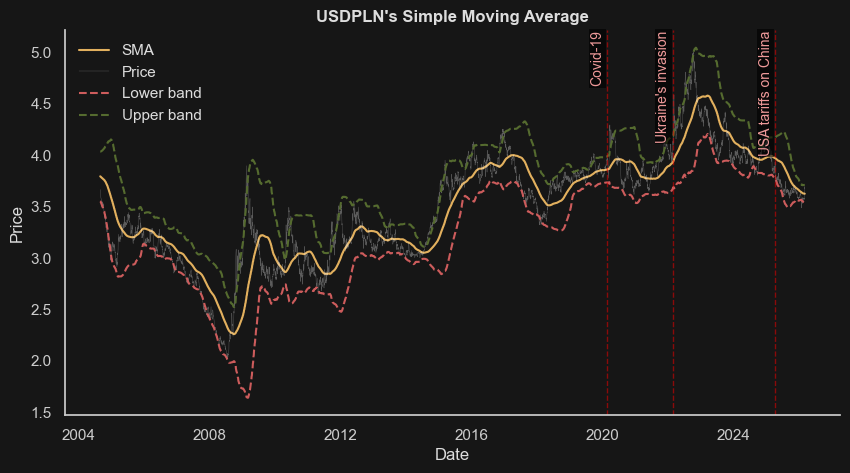

In [16]:
pl.sma_change_plot(data.close_prices, selected)

### 5. Long term hypothetical investment strategy
---

In [17]:
from src.investment_strategy_simulation import investment_strategy_sim
symbols_list = ["Brent Crude Oil", "Gold", "Silver", "Bitcoin", "Ethereum", "USDPLN", "Dow Jones", "S&P 500",
     "NASDAQ", "Russell 2000", "VIX"]

investment_strategy_sim(data.close_prices, symbols_list)


,symbol,Total invested PLN,Final investment value,Final profit,Final profit_perc
2,Silver,9000.0,18264.05,9264.05,102.93
1,Gold,9000.0,13248.05,4248.05,47.20
0,Brent Crude Oil,9000.0,10399.41,1399.41,15.55
9,Russell 2000,9000.0,10078.64,1078.64,11.98
10,VIX,9000.0,9966.51,966.51,10.74
8,NASDAQ,9000.0,9830.26,830.26,9.23
7,S&P 500,9000.0,9662.05,662.05,7.36
6,Dow Jones,9000.0,9538.17,538.17,5.98
5,USDPLN,9000.0,8502.06,-497.94,-5.53
3,Bitcoin,9000.0,7154.48,-1845.52,-20.51


### 6. Summary
---